# **Task 6 — Customer Churn Prediction**

---

**Author:** Shoaib Muhammad  
**Internship:** Neurofive Solutions — Machine Learning Track  
**Task:** Customer Churn Prediction  
**Dataset:** Telco Customer Churn Dataset  
**Models:** Decision Tree Classifier & Logistic Regression

---

## **Objective**

The objective of this task is to build machine learning models that predict customer churn using the Telco Customer Churn dataset.

In this task, Exploratory Data Analysis (EDA) is performed to understand the factors associated with churn, including contract type, tenure, and monthly charges. Categorical variables are handled using one-hot encoding, class imbalance is examined, and two classification models are trained: Decision Tree Classifier and Logistic Regression. Finally, model performance is compared and the top three churn-related features are identified using the Decision Tree's `feature_importances_`.


# **Import Libraries**

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# **Load Dataset**

In [2]:
# Load the Telco Customer Churn dataset
# The notebook was executed using the uploaded Telco Customer Churn CSV.

file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully.
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Understand the Dataset**

In [3]:
# Display dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset Information

In [4]:
# Statistical summary

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Data Cleaning**

In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])


Missing values in each column:
Series([], dtype: int64)


In [6]:
# Convert TotalCharges to numeric
# Some values may be stored as blank strings, so errors='coerce' converts them to NaN.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values after converting TotalCharges:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after converting TotalCharges:
TotalCharges    11
dtype: int64


In [7]:
# Remove rows with missing TotalCharges values

df = df.dropna().copy()

print("Dataset shape after cleaning:", df.shape)
print("Total missing values:", df.isnull().sum().sum())


Dataset shape after cleaning: (7032, 21)
Total missing values: 0


In [8]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


# **Exploratory Data Analysis (EDA)**

EDA is used to understand customer characteristics and identify patterns associated with churn before training the machine learning models.


## **Churn Distribution**

In [9]:
# Check churn counts and percentages

print("Churn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


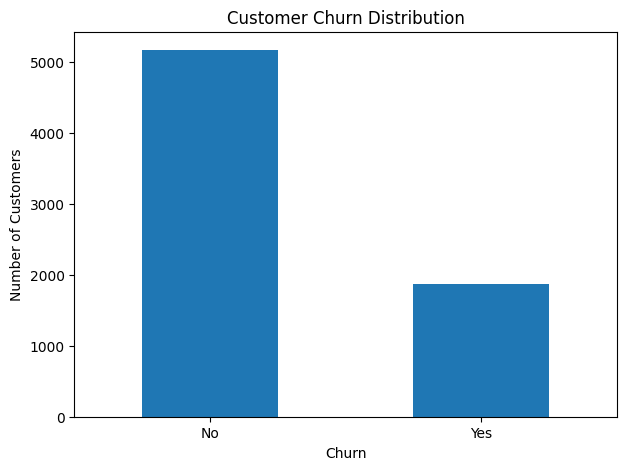

In [10]:
# Visualize churn distribution

df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()


### **Observation**

The dataset contains 5,163 customers who did not churn (73.42%) and 1,869 customers who churned (26.58%). This shows a moderate class imbalance, with non-churn customers making up the larger class. Therefore, accuracy should not be used as the only evaluation metric.

## **Contract Type vs Churn**

In [11]:
# Calculate churn distribution within each contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


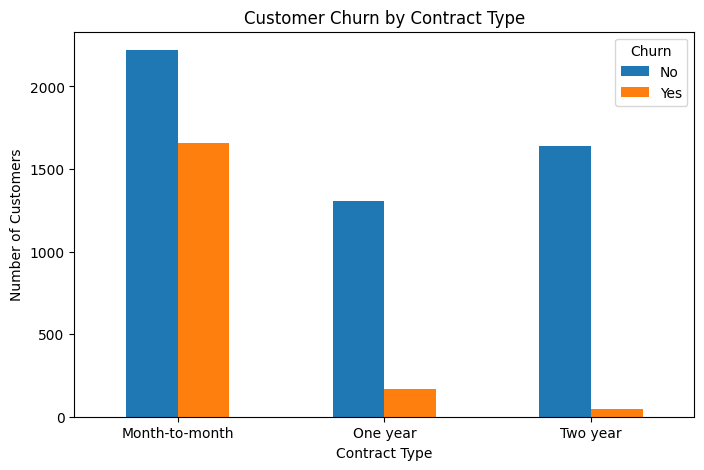

In [12]:
# Visualize contract type against churn

pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


### **Observation**

Contract type shows a strong relationship with churn. The churn rate is approximately **42.71% for month-to-month customers**, compared with **11.28% for one-year contracts** and **2.85% for two-year contracts**. This makes contract type an important business signal for retention strategies.

## **Tenure vs Churn**

In [13]:
# Compare average tenure for churned and retained customers

df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)


,count,mean,median,min,max
Churn,,,,,
No,5163,37.65,38.0,1,72
Yes,1869,17.98,10.0,1,72


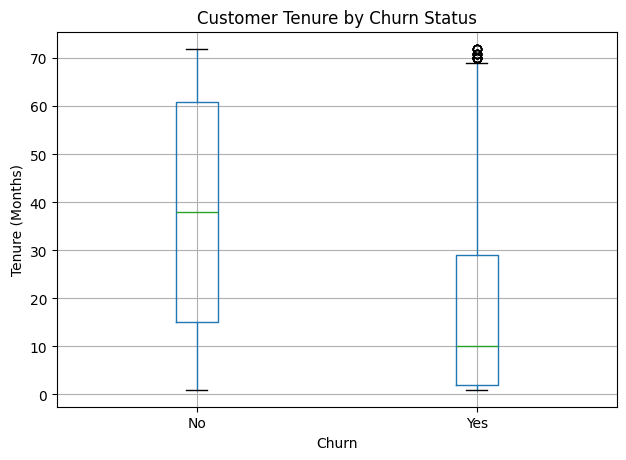

In [14]:
# Visualize tenure by churn status

df.boxplot(
    column="tenure",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()


### **Observation**

Customers who churned had an average tenure of **17.98 months**, while customers who stayed had an average tenure of **37.65 months**. This indicates that shorter customer relationships are associated with higher churn risk.

## **Monthly Charges vs Churn**

In [15]:
# Compare monthly charges for churned and retained customers

df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)


,count,mean,median,min,max
Churn,,,,,
No,5163,61.31,64.45,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


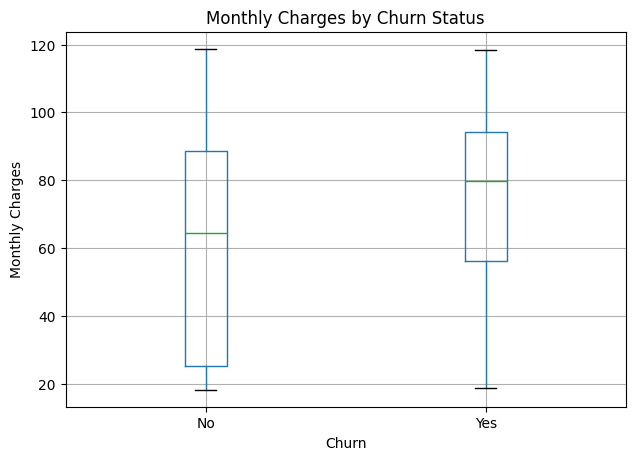

In [16]:
# Visualize monthly charges by churn status

df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


### **Observation**

Churned customers had a higher average monthly charge (**74.44**) than customers who stayed (**61.31**). This suggests that monthly charges are an important churn-related factor, although this relationship does not by itself prove causation.

## **Additional Churn Analysis**

In [17]:
# Churn distribution by Internet Service

pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


In [18]:
# Churn distribution by Payment Method

pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


# **Class Imbalance Analysis**

In [19]:
# Examine the class distribution

class_counts = df["Churn"].value_counts()
class_percentages = df["Churn"].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))


Class Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Class Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


### **Class Imbalance Observation**

The target distribution is **73.42% No Churn** and **26.58% Churn**. This is a moderate class imbalance. For this initial modeling task, a **stratified train-test split** was used to preserve the same class ratio in the training and testing sets.

Because churn is the minority class, accuracy alone is not sufficient. Precision, recall, F1-score, and ROC-AUC are also reported. In a future iteration, class-weighted models or other imbalance-handling techniques could be tested.

# **Data Preprocessing**

In [20]:
# Remove customerID because it is an identifier and does not provide
# meaningful predictive information for churn.

df = df.drop("customerID", axis=1)

# Convert target variable into binary values
# No = 0, Yes = 1

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Separate features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (7032, 19)
Target shape: (7032,)


In [21]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## **Handling Categorical Variables**

Categorical variables cannot be directly used by the scikit-learn models in their original text form. One-hot encoding converts each categorical value into numerical indicator variables.

A preprocessing pipeline is used so that the same transformations are applied consistently during training and testing.


In [22]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


# **Train-Test Split**

In [23]:
# Split data into training and testing sets.
# stratify=y preserves the churn/non-churn ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training set: (5625, 19)
Testing set: (1407, 19)

Training target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


# **Decision Tree Classifier**

In [24]:
# Create Decision Tree pipeline

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

# Train the model
decision_tree.fit(X_train, y_train)

# Generate predictions
dt_pred = decision_tree.predict(X_test)
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [25]:
# Evaluate Decision Tree

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


Decision Tree Performance
-------------------------
Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.615
F1 Score : 0.6085
ROC-AUC  : 0.8296

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.86      1033
       Churn       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



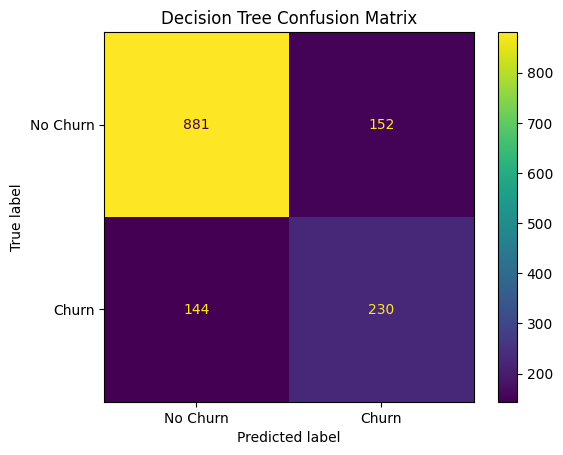

In [26]:
# Decision Tree confusion matrix

dt_cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


# **Logistic Regression**

In [27]:
# Create Logistic Regression pipeline

logistic_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_regression.fit(X_train, y_train)

# Generate predictions
lr_pred = logistic_regression.predict(X_test)
lr_prob = logistic_regression.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [28]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


Logistic Regression Performance
--------------------------------
Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1 Score : 0.608
ROC-AUC  : 0.8359

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



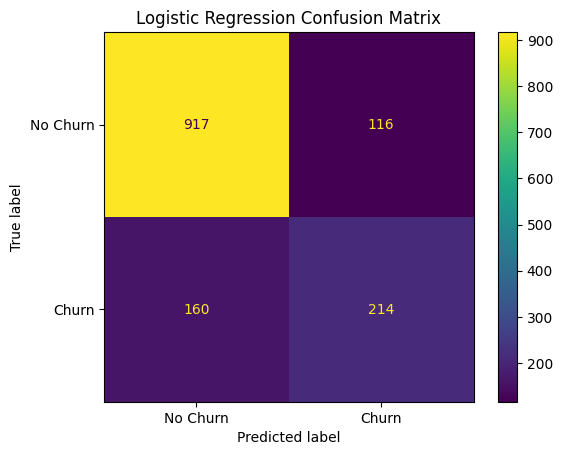

In [29]:
# Logistic Regression confusion matrix

lr_cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# **Model Comparison**

In [30]:
# Compare both models using multiple classification metrics

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression"
    ],
    "Accuracy": [
        dt_accuracy,
        lr_accuracy
    ],
    "Precision": [
        dt_precision,
        lr_precision
    ],
    "Recall": [
        dt_recall,
        lr_recall
    ],
    "F1 Score": [
        dt_f1,
        lr_f1
    ],
    "ROC-AUC": [
        dt_auc,
        lr_auc
    ]
})

results.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.7896,0.6021,0.6150,0.6085,0.8296
1,Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359


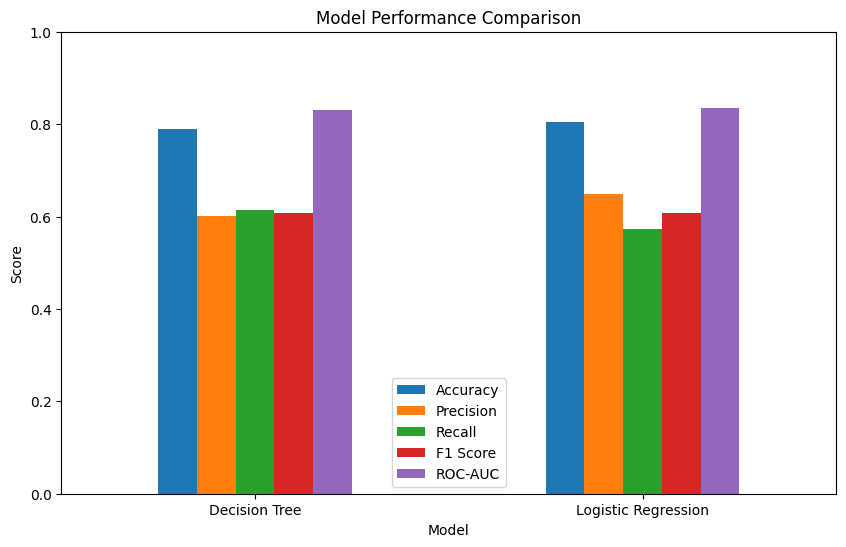

In [31]:
# Visual comparison

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()


### **Model Comparison Interpretation**

The **Logistic Regression** model achieved the higher overall accuracy (**80.38%**) and ROC-AUC (**0.8359**), as well as higher precision (**64.85%**). The **Decision Tree** achieved slightly higher recall (**61.50% vs. 57.22%**), meaning it identified a larger proportion of the actual churn cases in this test set.

The F1-scores were very similar (**0.6085 for Decision Tree** and **0.6080 for Logistic Regression**). For this dataset and configuration, Logistic Regression provides the stronger overall performance, while the Decision Tree remains useful because its decisions and feature importance are easier to explain to non-technical stakeholders.

# **Feature Importance — Decision Tree**

The Decision Tree provides `feature_importances_`, which can be used to identify the features that contributed most to its predictions.

Because categorical variables were one-hot encoded, some original variables are represented by multiple encoded features.


In [32]:
# Extract feature names after preprocessing

feature_names = (
    decision_tree
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract Decision Tree feature importance values

importance_values = (
    decision_tree
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)


,Feature,Importance
36,cat__Contract_Month-to-month,0.522339
16,cat__InternetService_Fiber optic,0.151209
3,num__TotalCharges,0.119405
1,num__tenure,0.069048
2,num__MonthlyCharges,0.035825
27,cat__TechSupport_No,0.033303
43,cat__PaymentMethod_Electronic check,0.015660
37,cat__Contract_One year,0.011837
35,cat__StreamingMovies_Yes,0.010663
10,cat__PhoneService_No,0.008565


## **Top 3 Features Driving Churn**

In [33]:
# Identify the top 3 features

top_3_features = feature_importance.head(3)

print("Top 3 Features Driving Churn:")
print(top_3_features.to_string(index=False))


Top 3 Features Driving Churn:
                         Feature  Importance
    cat__Contract_Month-to-month    0.522339
cat__InternetService_Fiber optic    0.151209
               num__TotalCharges    0.119405


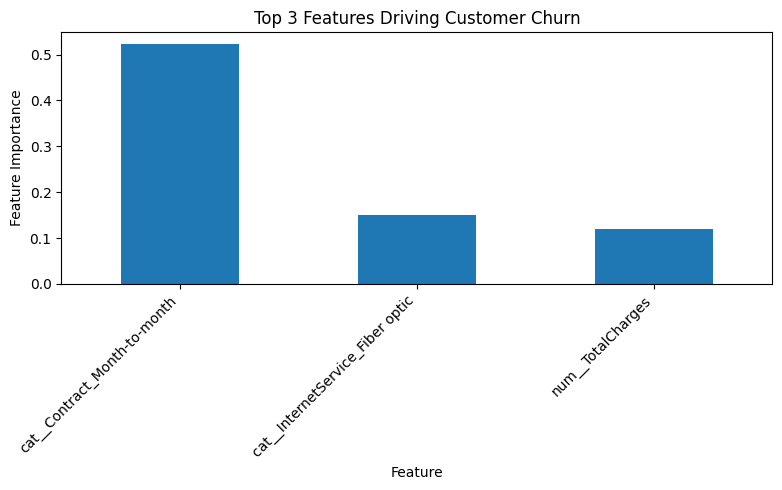

In [34]:
# Visualize top 3 features

top_3_features.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Top 3 Features Driving Customer Churn")
plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### **Feature Importance Interpretation**

The Decision Tree's top three encoded features are:

1. **Contract — Month-to-month:** 0.522339
2. **Internet Service — Fiber optic:** 0.151209
3. **Total Charges:** 0.119405

These values represent predictive importance within this trained Decision Tree; they should not be interpreted as proof that a feature directly causes churn. The particularly high importance of month-to-month contracts suggests that contract structure is a major signal for identifying customers at risk of leaving.

# **Business Summary**

The analysis found that **26.58% of customers churned**, with churn strongly associated with contract type, tenure, and customer charges. Month-to-month customers had a much higher churn rate (**42.71%**) than one-year (**11.28%**) and two-year (**2.85%**) customers. The Logistic Regression model achieved the best overall test performance with **80.38% accuracy and 0.8359 ROC-AUC**, while the Decision Tree provided slightly higher churn recall. The Decision Tree identified **month-to-month contract, fiber-optic internet service, and total charges** as its top three predictive features. These findings can support targeted retention actions, especially for higher-risk customers on month-to-month contracts.

# **Conclusion**

In this project, a complete customer churn prediction workflow was developed using the Telco Customer Churn dataset. The dataset was cleaned, exploratory analysis was performed, class imbalance was identified, and categorical variables were handled using one-hot encoding.

Two classification models were trained: **Decision Tree Classifier** and **Logistic Regression**. Logistic Regression achieved **80.38% accuracy and 0.8359 ROC-AUC**, while the Decision Tree achieved **78.96% accuracy and 0.8296 ROC-AUC**. The Decision Tree's top three predictive features were **month-to-month contract, fiber-optic internet service, and total charges**.

Overall, the results show that machine learning can help a business identify customers who are more likely to churn and support data-driven customer retention strategies.

## **Real Dataset Execution Note**

This notebook contains the actual outputs generated from the uploaded Telco Customer Churn dataset, including EDA results, model evaluation metrics, confusion matrices, model comparison, and Decision Tree feature importances.
